In [32]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

In [67]:
sns.set_palette("Set2")

In [68]:
df = pd.read_csv('Churn_Modelling.csv')

**Таблица:** данные содержат сведения о клиентах банка, целевая переменная представляет собой бинарную переменную, отражающую тот факт, покинул ли клиент банк (закрыл свой счет) или продолжает оставаться клиентом.

# Общая информаия

In [69]:
df.shape

(10000, 14)

In [70]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1855,1856,15570601,Cheng,785,France,Female,47,9,122031.55,1,1,1,33823.50,1
8857,8858,15810826,Chiekwugo,624,France,Male,36,6,0.00,2,0,0,84749.96,0
6447,6448,15614834,Long,619,Spain,Female,31,3,141751.82,1,0,1,61531.86,0
4852,4853,15574137,Ch'in,687,Spain,Male,35,3,0.00,2,1,1,176450.19,0
6874,6875,15793883,Lo Duca,798,France,Male,28,3,0.00,2,1,0,2305.27,0


In [71]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [72]:
df.isna().sum().to_frame().rename(columns={0: 'NULL values'})

,NULL values
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [73]:
df[df.duplicated()]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


**Выводы:**
- Датасет содержит 10000 строк и 14 столбцов
- Датасет не содержит пропусков
- Типы данных соответствуют ожидаемым
- Дубли отсутствуют

# Описательные статистики

In [74]:
df.describe(include=['int64', 'float64'])

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [75]:
df.describe(include=['object'])

,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


**Выводы:**
- В колонках `CreditScore`, `Age`, `Tenure` распределене, возможно, похоже на нормальное
- Судя по разнице между `mean` и `median`, `75%` и `max` в `Balance` возможны выбросы
- `HasCrCard`, `IsActiveMember` и `Exited` являются переменными-флагами, поэтому в них значение `mean` равно доле значений True для соответствующего признака. В `IsActiveMember` оно равно примерно половине, а в `HasCrCard` и `Exited` есть дисбаланс
- В `Geography` из трех возможных значений самое частотное встречается чаще, чем в 50% строках -> дисбаланс
- `Surname` имеет слишком много уникальных значений

# Детальная информация по признакам

In [76]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

### RowNumber, CustomerId и Surname - кандидаты для исключения из модели

In [77]:
df.RowNumber.nunique()

10000

In [78]:
df.CustomerId.nunique()

10000

In [79]:
df.Surname.nunique()

2932

**Вывод:** `RowNumber`, `CustomerId` - идентификаторы, не подлежат анализу. `Surname` - фамилия клиента, не имеет значения в рамках решаемой задачи

### Exited - целевая переменная - покинул ли клиент банк

In [80]:
df.Exited.nunique()

2

In [81]:
df.Exited.unique()

array([1, 0])

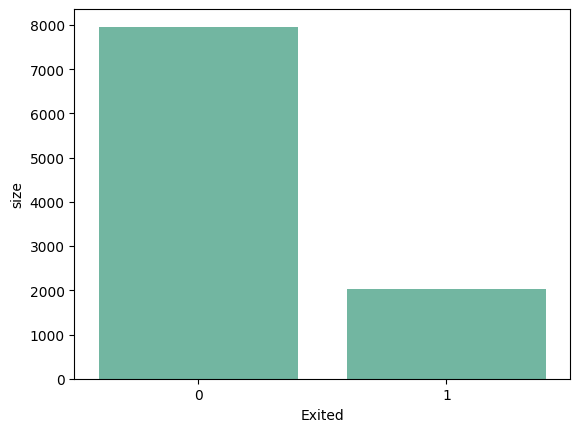

In [96]:
ax = sns.barplot(df.groupby('Exited', as_index=False).size(), x='Exited', y='size');

In [83]:
df.Exited.mean() * 100

20.369999999999997

**Вывод:** значения `Exited` соответствуют ожидаемым. По данным доля клиентов, покинувших банк - 20%

### CreditScore - кредитный рейтинг клиента

In [84]:
df.CreditScore.nunique()

460

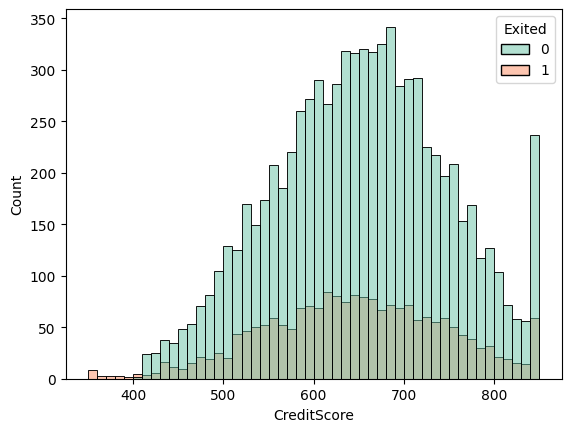

In [85]:
sns.histplot(df, x='CreditScore', bins=50, hue='Exited');

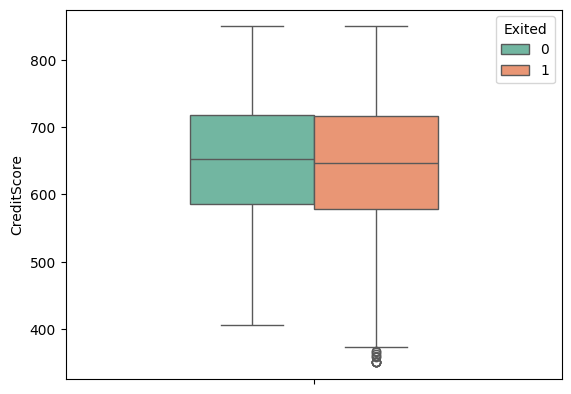

In [86]:
sns.boxplot(df, y='CreditScore', hue='Exited', width=0.5);

In [87]:
print(f"min = {df.CreditScore.min()}, max = {df.CreditScore.max()}")

min = 350, max = 850


**Вывод:** распределение `CreditScore` в целом похоже на нормальное, но максимальные значения слишком частотные. Клиенты, покинувшие банк и оставшиеся, в целом, имеют похожий кредитный рейтинг

### Geography - страна

In [91]:
df.Geography.unique()

array(['France', 'Spain', 'Germany'], dtype=object)

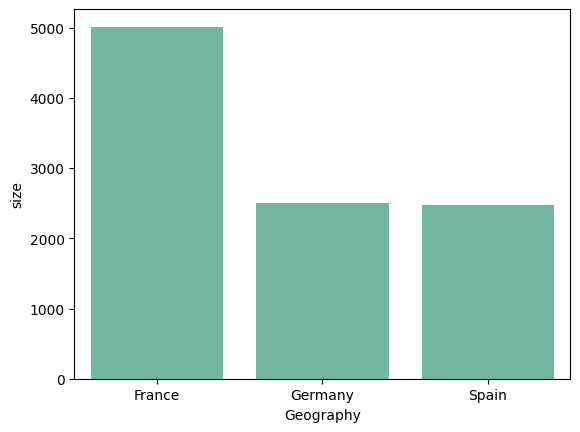

In [102]:
sns.barplot(df.groupby(['Geography'], as_index=False).size(), x='Geography', y='size');

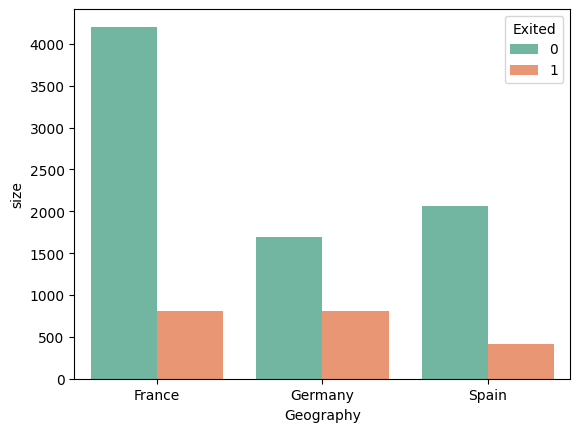

In [103]:
sns.barplot(df.groupby(['Geography', 'Exited'], as_index=False).size(), x='Geography', y='size', hue='Exited');

In [99]:
df.groupby(['Geography'], as_index=False).agg(count=('Exited', 'count'), exited_share=('Exited', 'mean'))

,Geography,count,exited_share
0,France,5014,0.161548
1,Germany,2509,0.324432
2,Spain,2477,0.166734


**Вывод:** 
- Половина клиентов из Франции
- Процент оттока для Франции и Испании одинаковй, а для Germany он выше

-> скорее всего, страна влияет на решение клиента покинуть банк

### Gender - пол клиента

In [101]:
df.Gender.unique()

array(['Female', 'Male'], dtype=object)

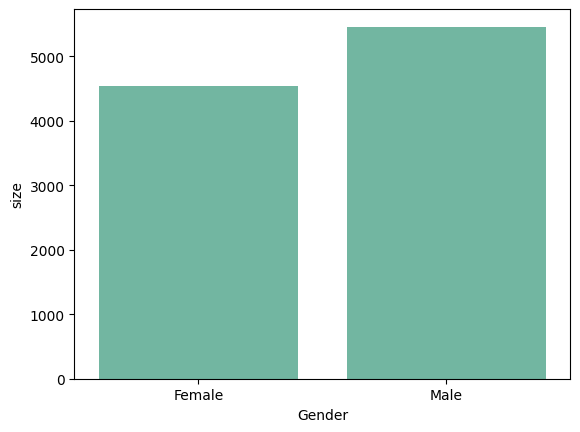

In [106]:
sns.barplot(df.groupby(['Gender'], as_index=False).size(), x='Gender', y='size');

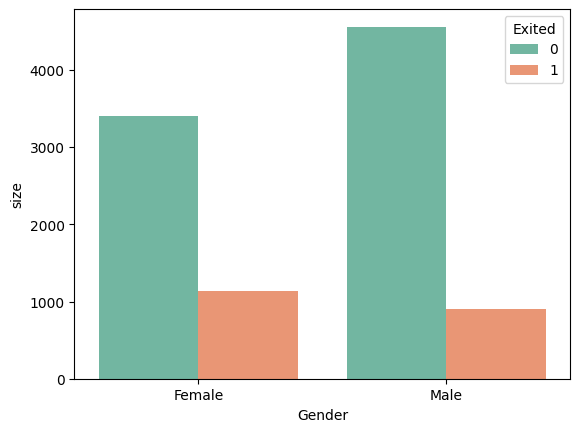

In [104]:
sns.barplot(df.groupby(['Gender', 'Exited'], as_index=False).size(), x='Gender', y='size', hue='Exited');

In [129]:
df.groupby(['Gender'], as_index=False).agg(count=('Exited', 'count'), exited_share=('Exited', 'mean'))

,Gender,count,exited_share
0,Female,4543,0.250715
1,Male,5457,0.164559


**Вывод:** 
- Вероятно, пол влияет на решение покинуть банк, т.к. среди женщин доля отказавшихся от услуг в 1.5 раза больше

### Age - возраст клиента

In [108]:
df.Age.nunique()

70

In [109]:
print(f"min = {df.Age.min()}, max = {df.Age.max()}")

min = 18, max = 92


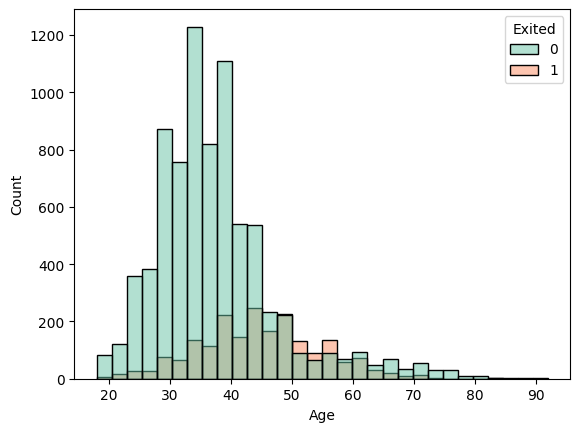

In [114]:
sns.histplot(df, x='Age', bins=30, hue='Exited');

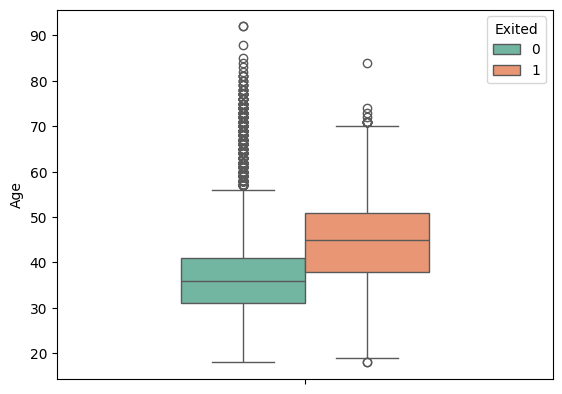

In [113]:
sns.boxplot(df, y='Age', hue='Exited', width=0.5);

**Вывод:** 
- Распределение отличается от нормального -> нужны преобразованя
- Возможно, клиенты старшего возраста больше склонны к отказу от услуг банка

### Tenure - сколько лет клиент пользуется банком

In [116]:
df.Tenure.unique()

array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0])

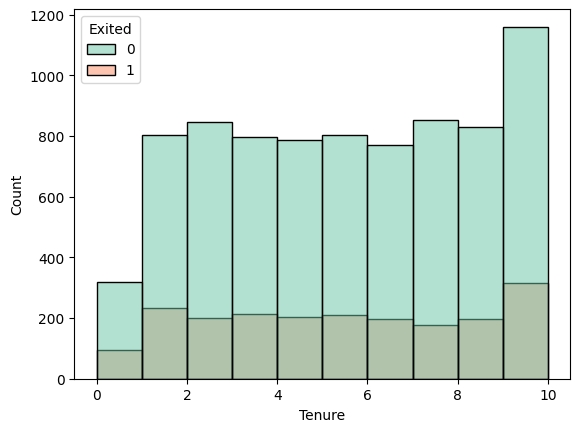

In [117]:
sns.histplot(df, x='Tenure', bins=10, hue='Exited');

**Вывод:** 
- Распределение близко к равномерному -> влияния на целевую переменную нет

### Balance - баланс банковского счета клиента

In [118]:
print(f"min = {df.Balance.min()}, max = {df.Balance.max()}")

min = 0.0, max = 250898.09


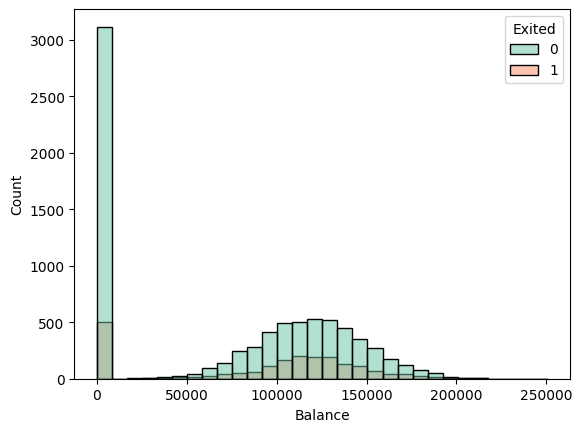

In [120]:
sns.histplot(df, x='Balance', bins=30, hue='Exited');

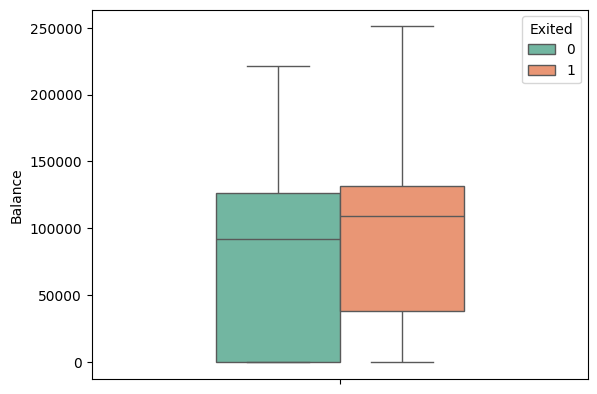

In [119]:
sns.boxplot(df, y='Balance', hue='Exited', width=0.5);

**Вывод:** 
- Много клиентов с нулевым балансом
- Среди клиентов с нулевым балансом доля отказов выше, чем среди клиентов с ненулевым балансом
- Распределение клиентов с ненулевым балансом близко к нормальному

### NumOfProducts - количество банковских продуктов, которыми пользуется клиент

In [123]:
df.NumOfProducts.unique()

array([1, 3, 2, 4])

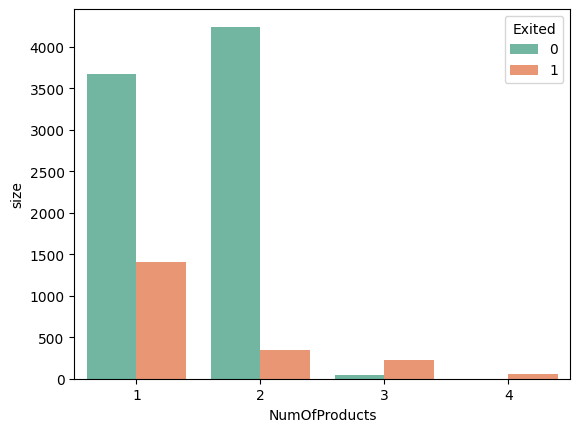

In [124]:
sns.barplot(df.groupby(['NumOfProducts', 'Exited'], as_index=False).size(), x='NumOfProducts', y='size', hue='Exited');

In [125]:
df.groupby(['NumOfProducts'], as_index=False).agg(count=('Exited', 'count'), exited_share=('Exited', 'mean'))

,NumOfProducts,count,exited_share
0,1,5084,0.277144
1,2,4590,0.075817
2,3,266,0.827068
3,4,60,1.000000


**Вывод:** 
- Есть дисбаланс в классах -> можно объединить клиентов, имеющих 3 или 4 продукта в один класс
- Самый низкий процент оттока среди клиентов, имеющих 2 продутка

### HasCrCard - есть ли у клиента кредитная карта

In [127]:
df.HasCrCard.unique()

array([1, 0])

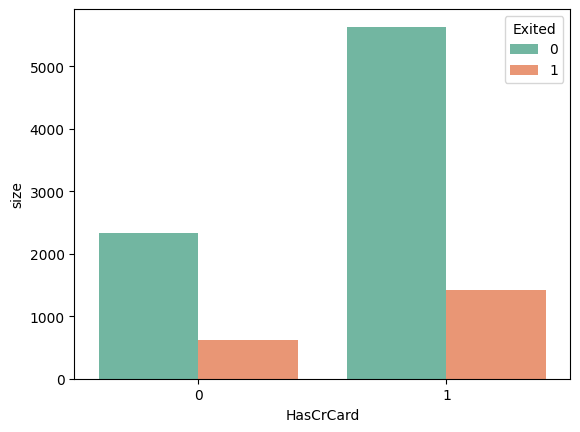

In [128]:
sns.barplot(df.groupby(['HasCrCard', 'Exited'], as_index=False).size(), x='HasCrCard', y='size', hue='Exited');

In [131]:
df.groupby(['HasCrCard'], as_index=False).agg(count=('HasCrCard', 'count'), exited_share=('Exited', 'mean'))

,HasCrCard,count,exited_share
0,0,2945,0.208149
1,1,7055,0.201843


**Вывод:** у большей части клиентов имеется кредитная карта, однако ее наличие не влияет на решение о том, чтобы покинуть банк

### IsActiveMember - является ли клиент активным пользователем

In [132]:
df.HasCrCard.unique()

array([1, 0])

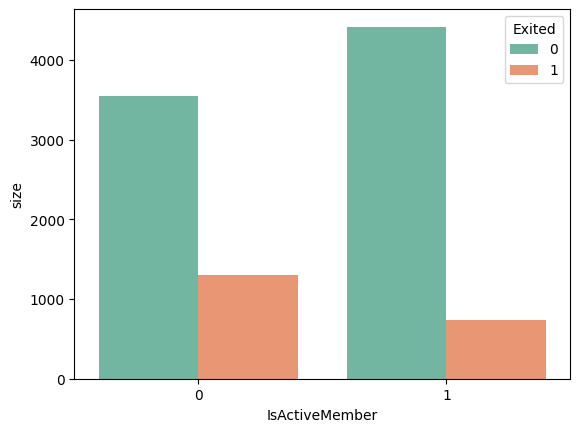

In [134]:
sns.barplot(df.groupby(['IsActiveMember', 'Exited'], as_index=False).size(), x='IsActiveMember', y='size', hue='Exited');

In [136]:
df.groupby(['IsActiveMember'], as_index=False).agg(count=('IsActiveMember', 'count'), exited_share=('Exited', 'mean'))

,IsActiveMember,count,exited_share
0,0,4849,0.268509
1,1,5151,0.142691


**Вывод**:
- Доля активных и неактивных клиентов примерно одинаковая
- Активные клиенты отказываются от баконковских услуг почти в 2 раза реже

### EstimatedSalary - предполагаемая заработанная плата клиента

In [137]:
print(f"min = {df.EstimatedSalary.min()}, max = {df.EstimatedSalary.max()}")

min = 11.58, max = 199992.48


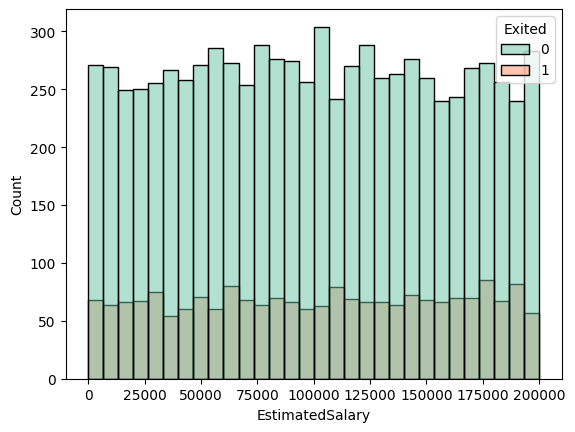

In [138]:
sns.histplot(df, x='EstimatedSalary', bins=30, hue='Exited');

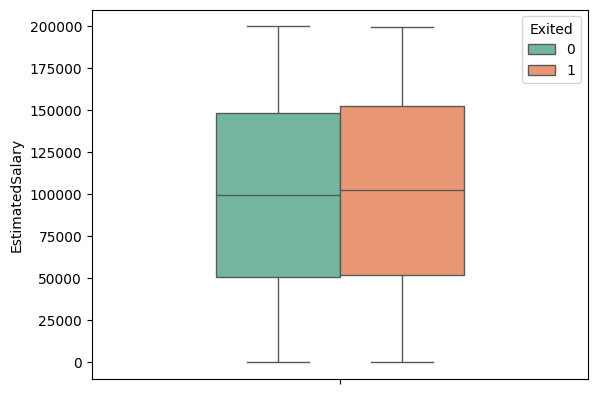

In [139]:
sns.boxplot(df, y='EstimatedSalary', hue='Exited', width=0.5);

**Вывод:**
- Распределения похожи -> вероятно, нет влияения на целевую переменную
- Распределения близки к равномерным. Для заработной платы это нетипично. Возможно, есть ошибка в данных

# Корреляции и зависимость между переменными

Рассчитаем корреляцию через `phik`. Метод позволяет вычислять взаимосвязи между различными типами признаков (категориальными, непрерывными и их комбинациями), в нем используются передовые статистические алгоритмы

In [142]:
import phik

interval columns not set, guessing: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


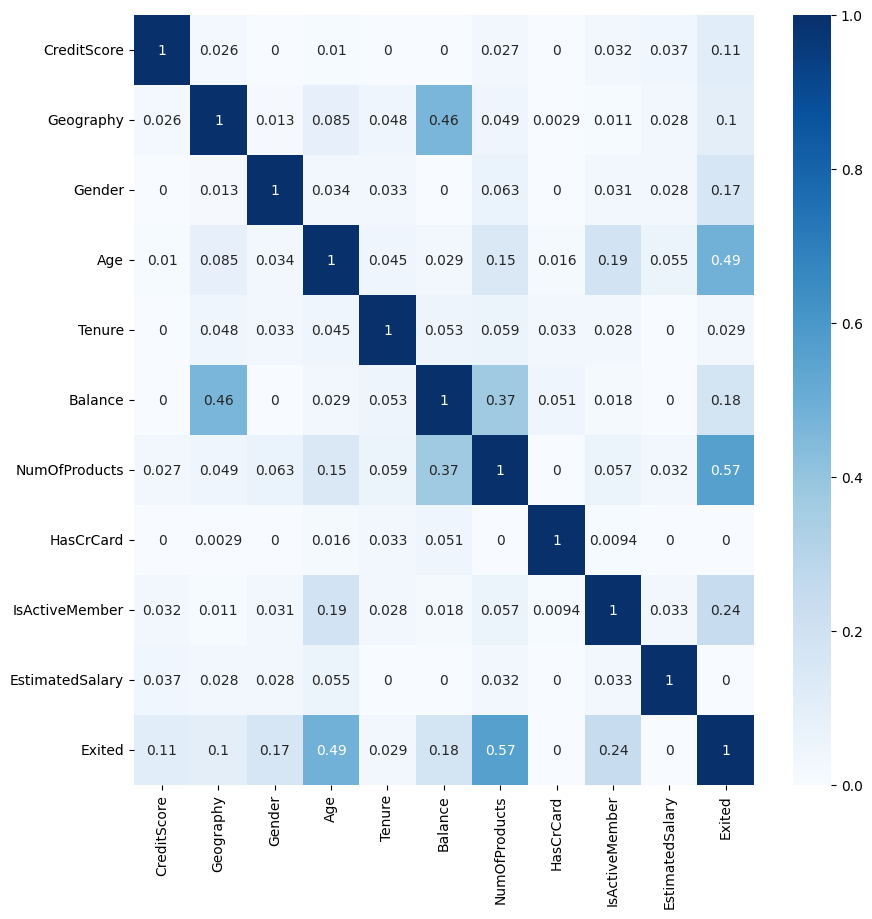

In [147]:
plt.figure(figsize=(10,10))

ph = df.drop(columns=['RowNumber', 'CustomerId', 'Surname']).phik_matrix()
sns.heatmap(ph, cmap="Blues", annot=True);

Рассмотрим зависимости между нецелевыми переменными

#### Geography и Balance

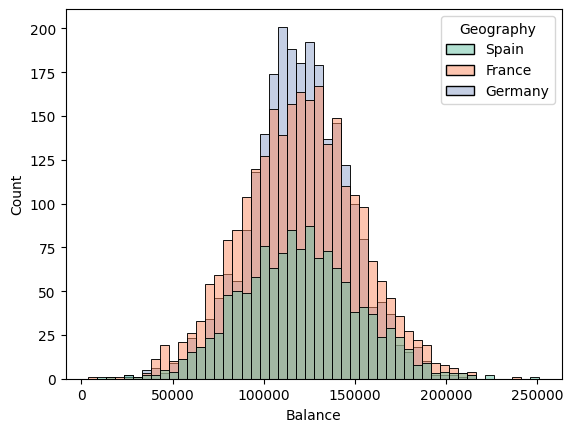

In [155]:
sns.histplot(df.query("Balance != 0"), x='Balance', bins=50, hue='Geography');

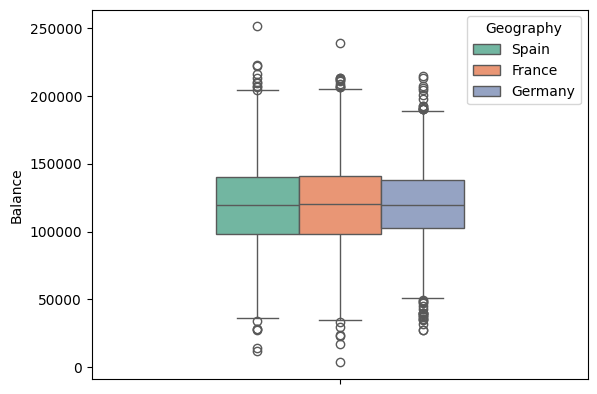

In [156]:
sns.boxplot(df.query("Balance != 0"), y='Balance', hue='Geography', width=0.5);

In [157]:
df['IsNullBalance'] = df.Balance.apply(lambda x: int(x == 0))

In [158]:
df.groupby(['Geography'], as_index=False).IsNullBalance.mean()

,Geography,IsNullBalance
0,France,0.482250
1,Germany,0.000000
2,Spain,0.484053


**Вывод:** в Германии нет клиентов с нулевым балансом -> смещение в данных

### Age и NumOfProducts

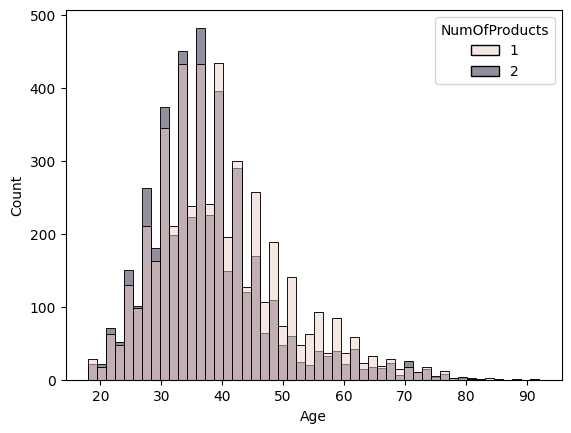

In [160]:
sns.histplot(df.query("NumOfProducts == 1 or NumOfProducts == 2"), x='Age', bins=50, hue='NumOfProducts');

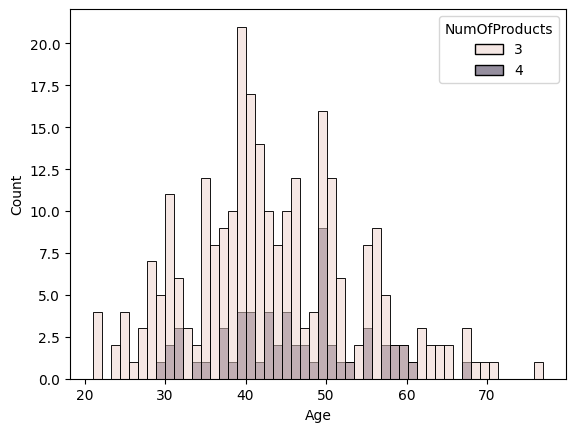

In [161]:
sns.histplot(df.query("NumOfProducts == 3 or NumOfProducts == 4"), x='Age', bins=50, hue='NumOfProducts');

### Age и IsActiveMember

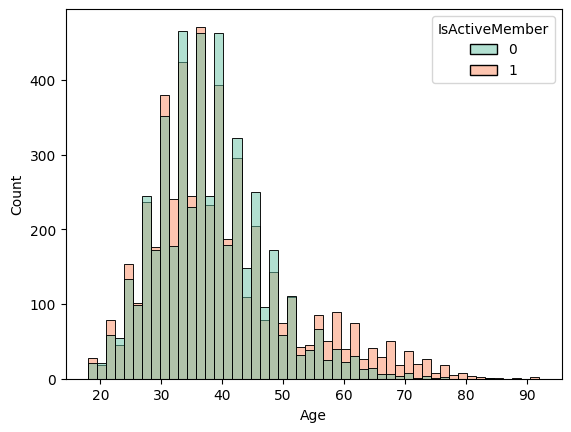

In [163]:
sns.histplot(df, x='Age', bins=50, hue='IsActiveMember');

### Balance и NumOfProducts

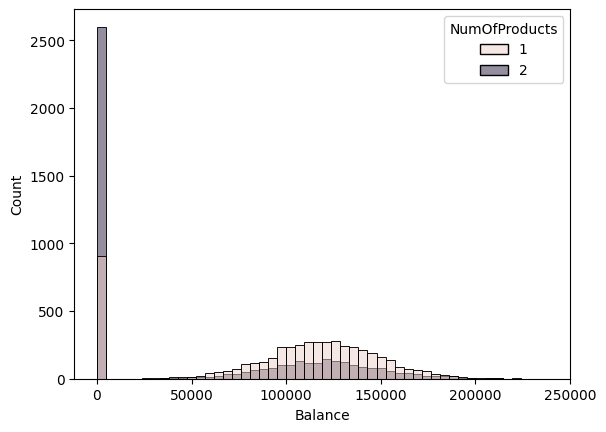

In [167]:
sns.histplot(df.query("NumOfProducts == 1 or NumOfProducts == 2"), x='Balance', bins=50, hue='NumOfProducts');

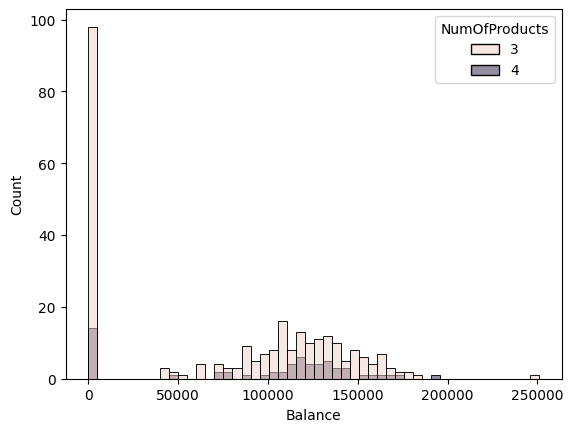

In [168]:
sns.histplot(df.query("NumOfProducts == 3 or NumOfProducts == 4"), x='Balance', bins=50, hue='NumOfProducts');

# Выводы

1. Датасет не содержит дублей и пропущенных значений. Из потенциальных ошибок - признак `EstimatedSalary` не похож на реальное распределение зарплат (т.к. его распределение равномерно)
2. Переменные с дисбалансом в классах / смещенным распределением:
    - `Exited` (целевая): соотношение классов 20 / 80
    - `Geography`: соотношение классов примерно 50 / 25 / 25
    - `Age`: распределение смещено влево, нужно преобразование 
    - `Balance`: около трети клиентов имеют нулевой баланс, распределение клиентов с ненулым балансов близко к нормальному
    - `NumOfProducts`: мало клиентов, имещих 3 или 4 прдукта -> можно их объединить в один класс
    - `HasCrCard`: соотношение классов 30 / 70
3. Целевая переменная `Exited` больше всего зависит от:
    - `NumOfProducts`, `Age` - но есть вероятность, что это из-за смещенных и дисбалансированных распределений
    - `IsActiveMember`
    - `Gender`
    - `Geography`
4. Зависимости между нецелевыми переменными:
    - `Geography` и `Balance` - вызвано тем, что в Германии нет клиентов с нулевым балансом 
    - `Age` и `NumOfProducts` - кажется, что у клиентов старшего возраста больше продуктов, но, возможно, это искажение из-за того, что молодых клиентов больше + классы не сбалансированы
    - `Age` и `IsActiveMember` - аналогично
    - `Balance` и `NumOfProducts` - в целом форма распределения похожа, но надо быть осторожнее, тк классы `NumOfProducts` не сбаланисрованы

В целом, данные ОК. Я бы выстраивала стратегию по их обработке в зависимости от результатов обучения моделей. Стат. значимость надо проверять осторожнее, т.к. много классов разных размеров